# Connexion à github

Pour github : à exécuter dans le terminal de colab

```bash
git clone https://github.com/MGentieu/dl_project.git

# CV Starter — Colab/Kaggle Quickstart

> Author : Badr TAJINI

**Academic year:** 2025–2026  
**School:** ECE  
**Course:** Machine Learning & Deep Learning 2

---


Welcome! This notebook is intentionally beginner-friendly. Follow the steps exactly and you will confirm that the starter project works on a free GPU runtime.

### Before you run anything
1. **Open the notebook in Google Colab or Kaggle.**
2. **Change the hardware accelerator to GPU (T4 preferred).**
   * Colab: `Runtime` → `Change runtime type` → Hardware accelerator `GPU` → Save.
   * Kaggle: `Settings` (gear icon) → Turn on `Accelerator` → Choose `T4 x1`.
3. Once the GPU is enabled, run the cells **from top to bottom**. Every code cell has comments explaining what it does.

The notebook will: (a) check that a GPU is available, (b) install dependencies, (c) run a quick smoke test that loads CIFAR-10 and performs one training step, and (d) show you how to launch the full training/evaluation commands when you are ready for longer experiments.

## 0. Project files

- Option A: `git clone <your_repo_url> cv-project`
- Option B: Upload the `cv-project` folder via the left sidebar (ensure the root is `/content/cv-project`).

Run the cell below afterwards; it will raise a helpful error if the folder is missing.

### Quick checklist before running code

- **Colab:** Go to `Runtime → Change runtime type`, pick `GPU`, and click **Save**.
- **Kaggle:** Open the gear icon in the top-right, enable **Accelerator**, and choose `T4 x1`.
- Wait for the runtime to restart (Colab shows `Connected` again).
- Then run every cell in order. If you see an error, stop, read the message, and re-run the cell after fixing the issue.

Once the smoke test succeeds you can run the full training and evaluation commands shown at the end of the notebook.

### How to run a cell
- Click the little ▶️ button on the left of a cell, or press **Shift + Enter** (Colab) / **Ctrl + Enter** (Kaggle).
- Wait for the cell to finish (a number like `[1]` appears once it is done).
- If a cell shows an error, read the message, fix the issue, and re-run that same cell before moving forward.


### Step 0 — Confirm the GPU is ready
Run the next cell. You should see a table with GPU details (name + memory).
If you get the message `nvidia-smi unavailable`, the runtime is still on CPU—go back to the checklist above and switch it to GPU, then rerun the cell.


In [1]:
!nvidia-smi || echo "nvidia-smi unavailable (CPU runtime)"

Sat Nov 29 16:50:25 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

On vérifie ensuite qu'on est bien en train d'utiliser un GPU. Si c'est le cas, la cellule en-dessous affiche **cuda** :

In [2]:
# Install required libraries
!pip -q install torch torchvision torchmetrics==1.4.0 matplotlib tqdm ultralytics datasets scikit-learn

# Set seeds for reproducibility
import torch, random, numpy as np
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Set device to GPU if available
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


### Step 1 — Point the notebook at the project folder
This cell makes sure Colab/Kaggle is looking at the `cv-project` directory.
If it raises a `FileNotFoundError`, you likely uploaded the folder to a different place. Use the file browser on the left to confirm the path, fix it, and rerun the cell.


In [3]:
import os
import sys
from pathlib import Path

# The user has provided the explicit path to the project root.
PROJECT_ROOT = Path("/content/dl_project/starters/cv-project-starter/cv-project")

print(f"Environment: Colab/Kaggle (remote server), using provided PROJECT_ROOT")

# Validate structure
if not (PROJECT_ROOT / "src").exists():
    raise FileNotFoundError(f"Missing src/ directory at {PROJECT_ROOT}")

# Setup Python path
os.chdir(PROJECT_ROOT)
src_path = str(PROJECT_ROOT / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

print(f"Project root: {PROJECT_ROOT}")
print(f"Working directory: {Path.cwd()}")


Environment: Colab/Kaggle (remote server), using provided PROJECT_ROOT
Project root: /content/dl_project/starters/cv-project-starter/cv-project
Working directory: /content/dl_project/starters/cv-project-starter/cv-project


### Installation du dataset

In [4]:
import torchvision as tv
tf_train = tv.transforms.Compose([tv.transforms.Resize(224), tv.transforms.RandomHorizontalFlip(), tv.transforms.ToTensor()])
tf_val   = tv.transforms.Compose([tv.transforms.Resize(224), tv.transforms.ToTensor()])
train = tv.datasets.Caltech101(root="./data", download=True, transform=tf_train)
# Create a small validation split:
val_size = int(0.1*len(train)); train, val = torch.utils.data.random_split(train, [len(train)-val_size, val_size])
val.dataset.transform = tf_val
print(len(train), len(val))

7810 867


### Step 2 — Install the project requirements
This command reads `requirements.txt` and installs exactly the same packages you would get locally.
Expect a lot of text output; that is normal. If installation fails, run the cell again before moving forward.


In [5]:
# Install project dependencies listed in requirements.txt
!pip install -r requirements.txt

### Step 3 — Run the smoke test
This quick check downloads CIFAR-10 (if needed), runs one mini-batch through the model, and saves `outputs/smoke_metrics.json`.
You should see a short JSON output such as `{"loss": ..., "batch_size": 64, ...}`.
If you hit a download or network error, wait a few seconds and re-run the cell; Colab sometimes needs a second try.


In [6]:
import yaml
cfg = yaml.safe_load(open("configs/cv_caltech101_fast.yaml"))
print(cfg["data"]["dataset"])


caltech101


In [7]:
from src.utils import load_yaml
cfg = load_yaml("configs/cv_caltech101_fast.yaml")
print(cfg["data"]["dataset"])

caltech101


In [11]:
from src import smoke_check

smoke_path = smoke_check.run_smoke("configs/cv_caltech101_fast.yaml")
print(smoke_path.read_text())

RuntimeError: Caught RuntimeError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/worker.py", line 349, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/fetch.py", line 50, in fetch
    data = self.dataset.__getitems__(possibly_batched_index)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataset.py", line 416, in __getitems__
    return [self.dataset[self.indices[idx]] for idx in indices]
            ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torchvision/datasets/caltech.py", line 118, in __getitem__
    img = self.transform(img)
          ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torchvision/transforms/transfo

> **Why run the smoke test?**

> The smoke test is a safety check before long training. It loads CIFAR‑10, runs a single forward/backward pass, and writes outputs/smoke_metrics.json. If this succeeds, you know:

> - the dataset can be downloaded/read,
> - the model compiles and runs on your GPU,
> - dependencies are installed correctly.
>
> In short, if it fails, fix the error (missing folder, bad install, no GPU) before investing time in a full training run :
>
> *After !python src/evaluate.py ... (Step 4 below)*

## 1. Review smoke-test output
- Confirm the previous cell printed a JSON block (loss, batch size, device).
- You should now see `outputs/smoke_metrics.json` in the file browser on the left.
- Need only a quick check? You can stop here. Ready for real training? Continue to Section 2 below.
- If anything failed, read the error message carefully, fix the issue, and re-run the smoke cell before moving on.


## 2. Full training run (optional)
Only run these cells when you want the complete experiment. On the first run PyTorch will also download CIFAR-10, so the first epoch may start slowly.

**Before running:**
1. Open `configs/cv_cifar10.yaml` (Menu → File → Open …) if you want to change hyperparameters.
2. Ensure the runtime still shows a GPU connection.
3. Close other browser tabs or notebooks to avoid memory pressure.


In [ ]:
# Train the model using the main configuration file. Expect visible progress bars.
# The first time you run this it will also download CIFAR-10, so the progress bar
# might pause around 0% while data is fetched.
!python src/train.py --config configs/cv_cifar10.yaml

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Done. Best val acc: 0.9517. Checkpoint: outputs/best.pt


In [ ]:
# Evaluate the best checkpoint produced during training.
# This will print accuracy and write the metrics/plots listed below.
!python src/evaluate.py --config configs/cv_cifar10.yaml --ckpt outputs/best.pt

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Accuracy: 0.9517. Saved eval.json, per_class_metrics.csv, confusion_matrix.png, and leaderboard.png in outputs


### Step 4 — What should I see now?
- `outputs/best.pt`: saved checkpoint.
- `outputs/log.csv`: training history (loss/accuracy per epoch).
- `outputs/eval.json`, `per_class_metrics.csv`, `confusion_matrix.png`, `leaderboard.png`: evaluation artefacts.

If any of these files are missing, scroll up for errors in the training/evaluation cells.


## 3. Mirror this workflow for other tracks

1. Duplicate this notebook and rename it (e.g., `00_nlp_quickstart.ipynb`).
2. Copy the corresponding starter folder into your Colab/Kaggle workspace (`nlp-project`, `od-project`, `ts-project`).
3. Update the install cell so it matches that starter's `requirements.txt`.
4. Replace `from src import smoke_check` with the helper module provided in the new starter (each repo ships with one).
5. Point the train/eval commands at the new `configs/*.yaml` file.
6. Optionally tweak the markdown text so instructions mention the right dataset and metrics.

By following the same structure—GPU check → install → smoke test → full run—students can master all four tracks with a consistent workflow.

# On affiche à présent les résultats obtenus :

1. Affichage des métriques globales du modèle :

In [ ]:
import json

with open("outputs/metrics.json", "r") as f:
    metrics = json.load(f)

metrics

{'best_val_acc': 0.9517000317573547,
 'classes': ['airplane',
  'automobile',
  'bird',
  'cat',
  'deer',
  'dog',
  'frog',
  'horse',
  'ship',
  'truck']}

2. Affichage de la matrice de confusion

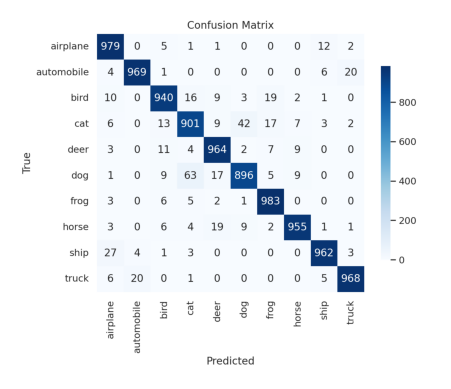

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("outputs/confusion_matrix.png")
plt.imshow(img)
plt.axis('off')
plt.show()


3. Affichage de leaderboard

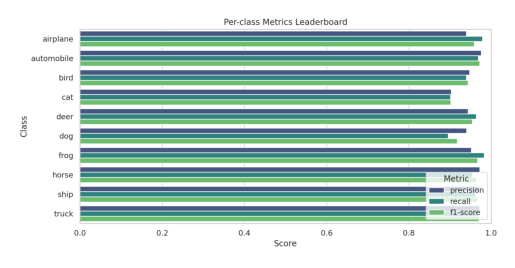

In [ ]:
img = Image.open("outputs/leaderboard.png")
plt.imshow(img)
plt.axis('off')
plt.show()


4. Affichage des résultats en fonction des époques

In [ ]:
import pandas as pd

df_logs = pd.read_csv("outputs/log.csv")
df_logs.head()


,epoch,train_loss,val_loss,val_acc
0,1,0.4352,0.2599,0.9100
1,2,0.1909,0.1826,0.9356
2,3,0.1082,0.1456,0.9517


5. Affichage des métriques du meilleur modèle par classe

In [ ]:
df_per_class = pd.read_csv("outputs/per_class_metrics.csv")
df_per_class


,Unnamed: 0,precision,recall,f1-score,support
0,airplane,0.9395,0.979,0.9589,1000.0
1,automobile,0.9758,0.969,0.9724,1000.0
2,bird,0.9476,0.940,0.9438,1000.0
3,cat,0.9028,0.901,0.9019,1000.0
4,deer,0.9442,0.964,0.9540,1000.0
5,dog,0.9402,0.896,0.9176,1000.0
6,frog,0.9516,0.983,0.9670,1000.0
7,horse,0.9725,0.955,0.9637,1000.0
8,ship,0.9717,0.962,0.9668,1000.0
9,truck,0.9719,0.968,0.9699,1000.0


6. Évolution de la fonction de perte à l'entraînement et à la validation en fonction des époques

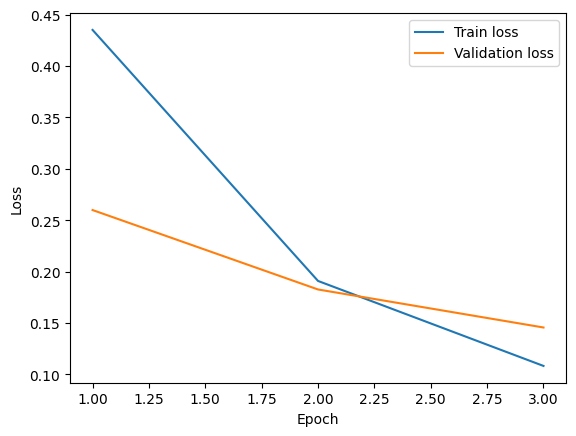

In [ ]:
plt.plot(df_logs['epoch'], df_logs['train_loss'], label='Train loss')
plt.plot(df_logs['epoch'], df_logs['val_loss'], label='Validation loss')
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


7. Affichage des métriques globales pour le meilleur modèle obtenu.

In [ ]:
with open("outputs/eval.json") as f:
    eval_results = json.load(f)

eval_results


{'val_acc': 0.9517000317573547,
 'macro_precision': 0.9517824779767802,
 'macro_recall': 0.9517,
 'macro_f1': 0.9515981059666588,
 'weighted_precision': 0.9517824779767802,
 'weighted_recall': 0.9517,
 'weighted_f1': 0.9515981059666588,
 'accuracy': 0.9517,
 'num_samples': 10000,
 'classes': ['airplane',
  'automobile',
  'bird',
  'cat',
  'deer',
  'dog',
  'frog',
  'horse',
  'ship',
  'truck']}